In [11]:
import numpy as np
import h5py
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
plt.rcParams['font.size'] = 14


from sk_decoder import RetinaDecoder
from sk_train_decoder import RGCDataset
from sk_utils import Utils as u

# Limited training set size (test)

In [80]:
results = torch.load("/home/rotation/Desktop/LNP_LN_LN_Models/test_weights_final.pt")
results.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

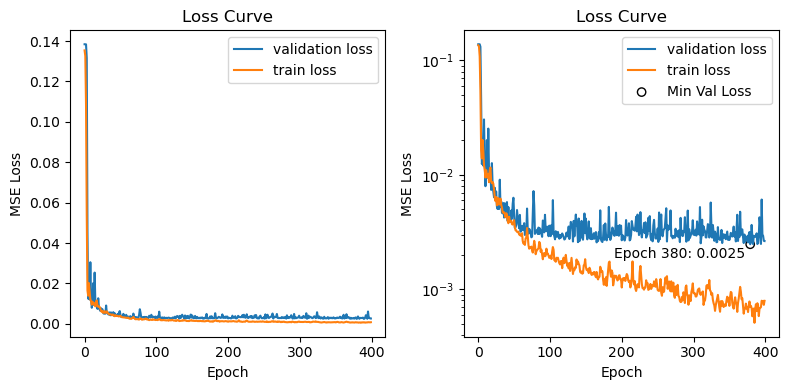

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(results["val_loss_history"], label="validation loss")
ax[0].plot(results["train_loss_history"], label="train loss")
ax[0].legend()

ax[0].set_title("Loss Curve")
ax[0].set_ylabel("MSE Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(results["val_loss_history"], label="validation loss")
ax[1].plot(results["train_loss_history"], label="train loss")

# show the minimum validation loss model
ax[1].scatter(379, min(results["val_loss_history"]), edgecolor="black", marker="o", facecolor="none", label="Min Val Loss")
ax[1].text(379-190, min(results["val_loss_history"])-0.0006, f"Epoch 380: {min(results['val_loss_history']):.4f}")
ax[1].legend()

ax[1].set_yscale("log")
ax[1].set_title("Loss Curve")
ax[1].set_ylabel("MSE Loss")
ax[1].set_xlabel("Epoch")

fig.set_tight_layout(True)
plt.show()

In [86]:
# Let's see if we can rebuild some of the input images (and if we can try to rebuild some out of distribution images)
# 1. Load Configurations
train_cfg = u.read_params("params_training.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Data Preparation
dataset = RGCDataset("test_activations.pt", "params_training.yaml")

# Validation split
val_split = train_cfg.get("validation_split", 0.1)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=False, num_workers=0)

# 3. Model Initialization
n_mosaics, max_n_cells, _ = dataset.firing_rates.shape
decoder_params = {
    "n_cells": n_mosaics * max_n_cells * dataset.input_window,
    "frame_shape": dataset.video_info["shape"][1:],
    "num_blocks": train_cfg.get("num_blocks", 4),
    "num_kernels": train_cfg.get("num_kernels", 64),
    "bias": train_cfg.get("bias", False)
}

model = RetinaDecoder(decoder_params).to(device)
model.load_state_dict(torch.load("test_weights.pt")["model_state_dict"])
model.eval()

Loading video from /home/rotation/Desktop/LNP_LN_LN_Models/lnp_naturalmovies/Video_2.mp4...
Full video loaded: 898 frames, 1080x1920 resolution, 30.000011135861595 FPS.
Cropping video to 128x128 starting at (350, 500)...


RetinaDecoder(
  (w): Linear(in_features=6404, out_features=65536, bias=True)
  (mid_block): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BF_batchNorm()
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (upsample): ModuleDict(
    (3): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2), bias=False)
  )
  (decoder): ModuleDict(
    (3): Sequential(
      (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BF_batchNorm()
      (2): ReLU(inplace=True)
      (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BF_b

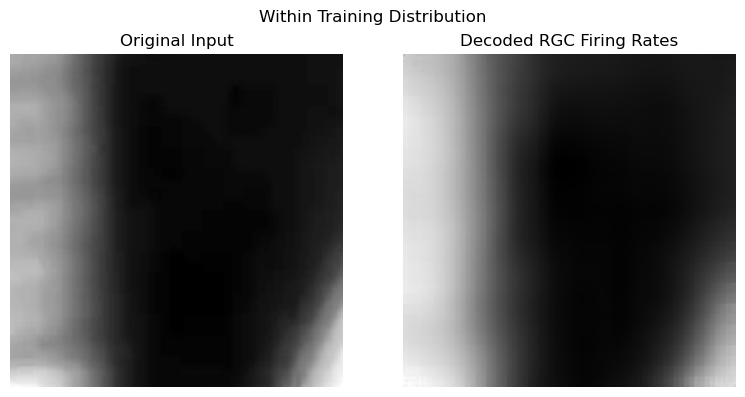

In [110]:
for x,y in train_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 63

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Training Distribution")
fig.set_tight_layout(True)
plt.show()

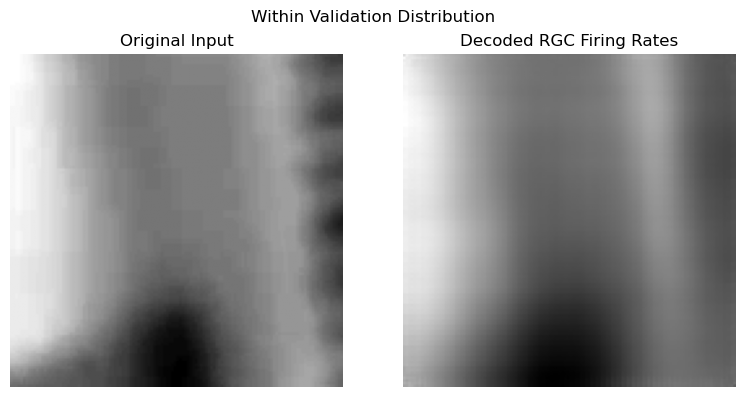

In [107]:
# what about something from the validation set?
for x,y in val_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 39

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Validation Distribution")
fig.set_tight_layout(True)
plt.show()

In [ ]:
# what about something entirely out of distribution
# let's try something a bit crazy:
# regenerating the entire video by creating patches from every portion of the video
!conda activate lnp_torch
!python sk_generate_activations.py

# Large training set size
uses multiple videos and few patches across each video, specifically from the chicago motion database

In [3]:
results = torch.load("/home/rotation/Downloads/CMD/models/CMD_best_decoder_final.pt")
results.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

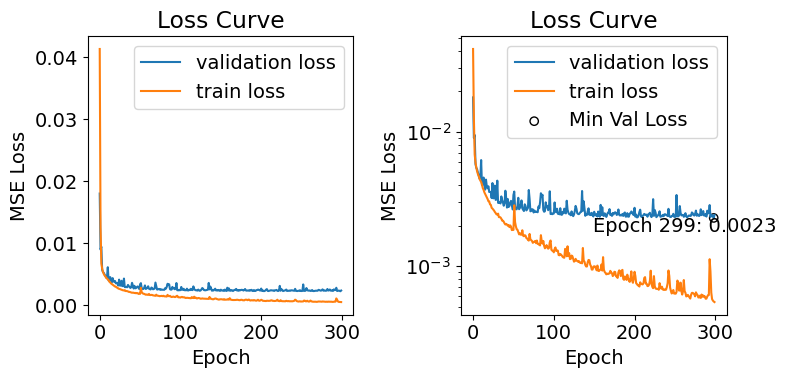

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(results["val_loss_history"], label="validation loss")
ax[0].plot(results["train_loss_history"], label="train loss")
ax[0].legend()

ax[0].set_title("Loss Curve")
ax[0].set_ylabel("MSE Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(results["val_loss_history"], label="validation loss")
ax[1].plot(results["train_loss_history"], label="train loss")

# show the minimum validation loss model
ax[1].scatter(298, min(results["val_loss_history"]), edgecolor="black", marker="o", facecolor="none", label="Min Val Loss")
ax[1].text(298-150, min(results["val_loss_history"])-0.0005, f"Epoch 299: {min(results['val_loss_history']):.4f}")
ax[1].legend()

ax[1].set_yscale("log")
ax[1].set_title("Loss Curve")
ax[1].set_ylabel("MSE Loss")
ax[1].set_xlabel("Epoch")

fig.set_tight_layout(True)
plt.show()

In [5]:
# Let's see if we can rebuild some of the input images (and if we can try to rebuild some out of distribution images)
# 1. Load Configurations
train_cfg = u.read_params("params_training.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Data Preparation
dataset = RGCDataset("/home/rotation/Downloads/CMD/testing/Video_1_activations.pt", "params_training.yaml")

# Validation split
val_split = train_cfg.get("validation_split", 0.1)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=False, num_workers=0)

# 3. Model Initialization
n_mosaics, max_n_cells = dataset.n_mosaics, dataset.max_n_cells
decoder_params = {
    "n_cells": n_mosaics * max_n_cells * dataset.input_window,
    "frame_shape": dataset.frame_shape,
    "num_blocks": train_cfg.get("num_blocks", 4),
    "num_kernels": train_cfg.get("num_kernels", 64),
    "bias": train_cfg.get("bias", False)
}

model = RetinaDecoder(decoder_params).to(device)
model.load_state_dict(torch.load("best_decoder.pt")["model_state_dict"])
model.eval()

OSError: Unable to synchronously open file (file signature not found)

In [6]:
for x_train,y_train in train_loader:
    break
x_train.shape, y_train.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 63

ax[0].imshow(y_train[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_val_cuda = x_train.to(device)
Y_train_pred = model(x_train_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Training Distribution")
fig.set_tight_layout(True)
plt.show()

NameError: name 'train_loader' is not defined

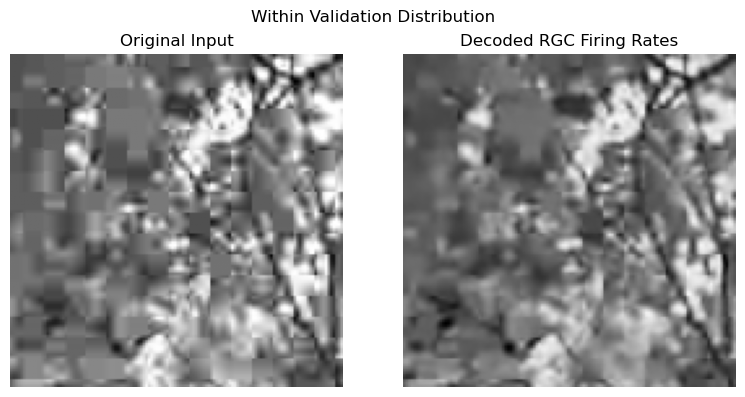

In [63]:
# what about something from the validation set?
for x_val,y_val in val_loader:
    break
x_val.shape, y_val.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 39

ax[0].imshow(y_val[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_val_cuda = x_val.to(device)
Y_val_pred = model(x_val_cuda)
ax[1].imshow(Y_val_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Validation Distribution")
fig.set_tight_layout(True)
plt.show()

YOO! turns out training on multiple datasets with multiple patches from each dataset actually works! who would have thought :))
Anyways, on recreating a video, check sk_reconstruct_video.py

## Blocking single cell types
Let's try reproducing these same images, but this time, when reproducing the images, we'll 0-out one cell type to see what the reproduced image looks like. This should give us some information about what that specific cell type is doing and what information it's capturing<br><br>

Cell types are organized in order ON parason, OFF parasol, ON midget, OFF midget

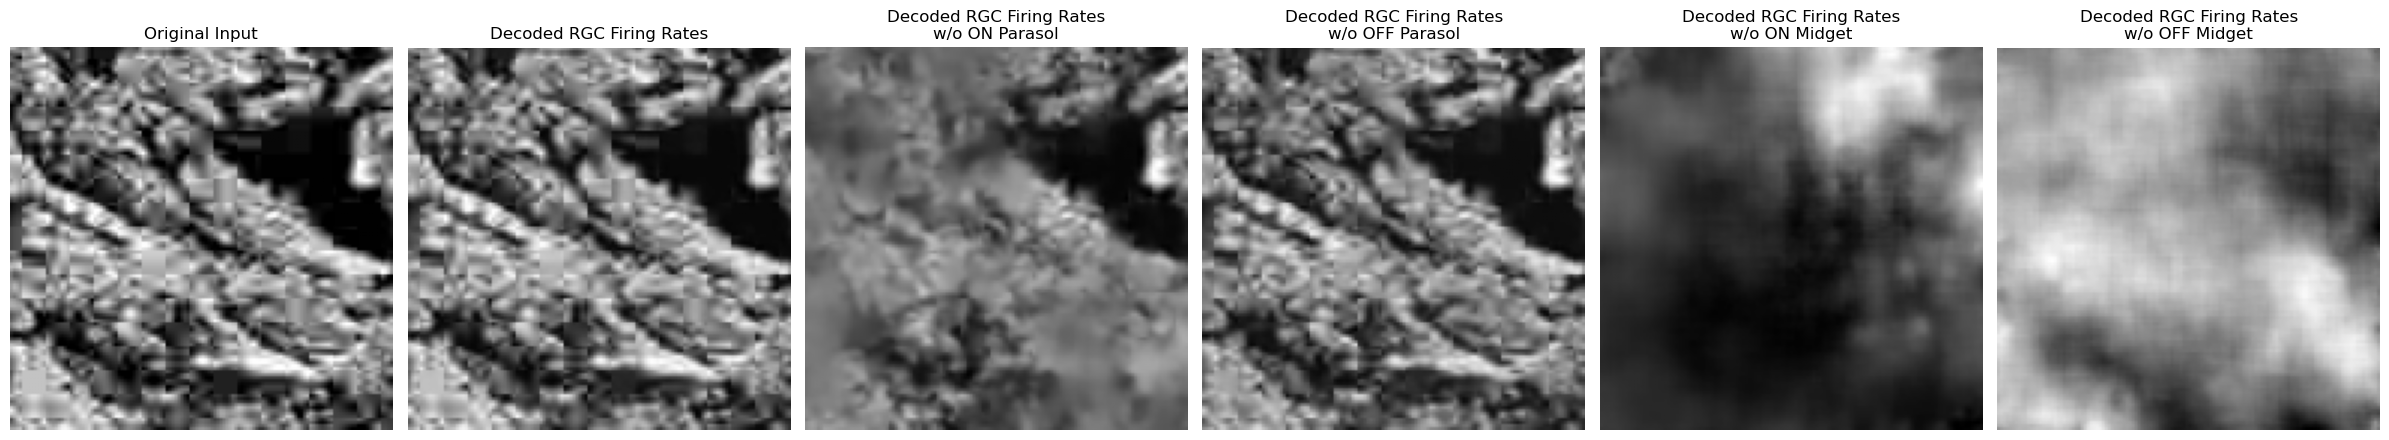

In [62]:
fig, ax = plt.subplots(1, 6, figsize=(24, 6))
ex = 63

ax[0].imshow(y_train[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# split our data into 4 samples with each missing a cell type
x_train_onparasol = x_train.clone(); x_train_onparasol[:,0,:,:] = 0.
x_train_offparasol = x_train.clone(); x_train_offparasol[:,1,:,:] = 0.
x_train_onmidget = x_train.clone(); x_train_onmidget[:,2,:,:] = 0.
x_train_offmidget = x_train.clone(); x_train_offmidget[:,3,:,:] = 0.

# do the forward pass (all cell types)
x_train_cuda = x_train.to(device)
Y_train_pred = model(x_train_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

# do the forward pass (no on parasol cells)
x_train_cuda = x_train_onparasol.to(device)
Y_train_pred = model(x_train_cuda)
ax[2].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[2].set_title("Decoded RGC Firing Rates\nw/o ON Parasol")

# do the forward pass (no off parasol cells)
x_train_cuda = x_train_offparasol.to(device)
Y_train_pred = model(x_train_cuda)
ax[3].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[3].set_title("Decoded RGC Firing Rates\nw/o OFF Parasol")

# do the forward pass (no on midget cells)
x_train_cuda = x_train_onmidget.to(device)
Y_train_pred = model(x_train_cuda)
ax[4].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[4].set_title("Decoded RGC Firing Rates\nw/o ON Midget")

# do the forward pass (no off midget cells)
x_train_cuda = x_train_offmidget.to(device)
Y_train_pred = model(x_train_cuda)
ax[5].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[5].set_title("Decoded RGC Firing Rates\nw/o OFF Midget")

for a in ax:
    a.axis("off")
    
fig.set_tight_layout(True)
plt.show()

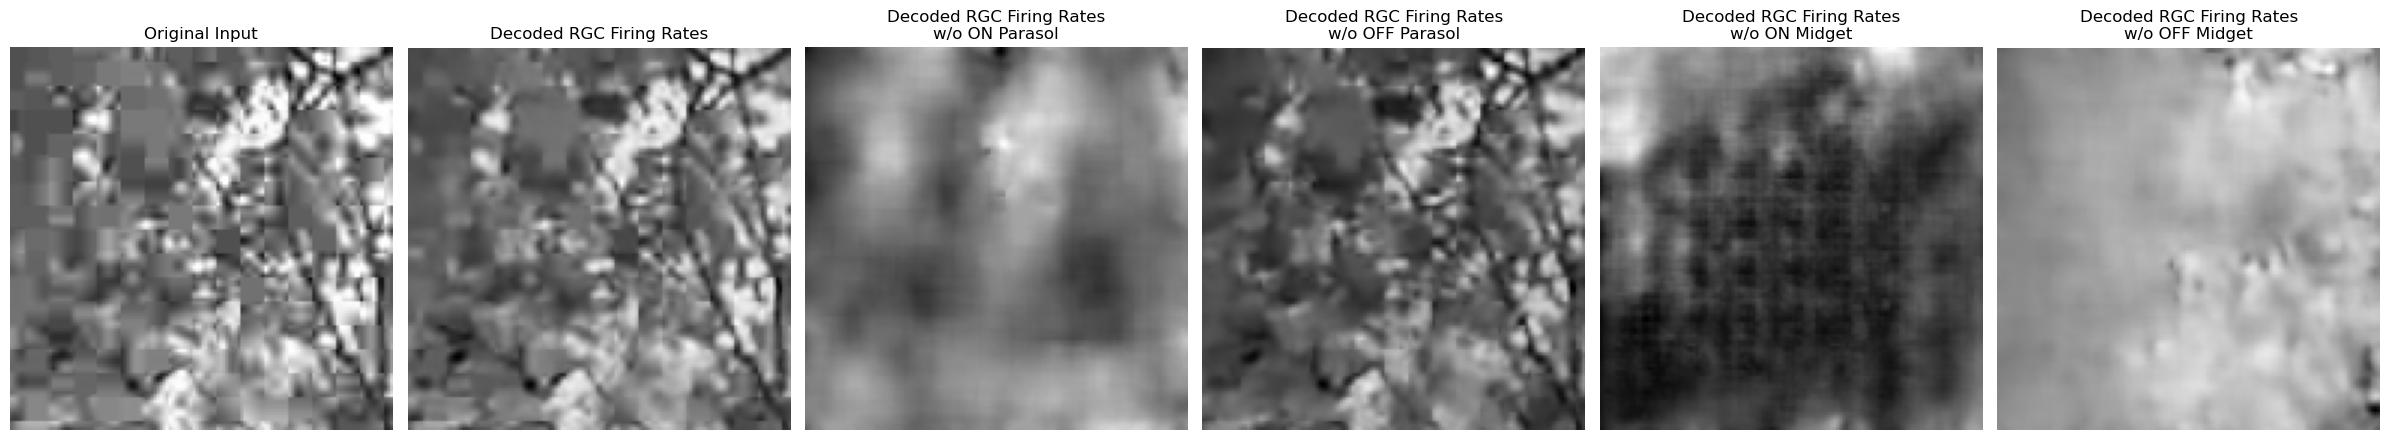

In [65]:
fig, ax = plt.subplots(1, 6, figsize=(24, 6))
ex = 39

ax[0].imshow(y_val[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# split our data into 4 samples with each missing a cell type
x_val_onparasol = x_val.clone(); x_val_onparasol[:,0,:,:] = 0.
x_val_offparasol = x_val.clone(); x_val_offparasol[:,1,:,:] = 0.
x_val_onmidget = x_val.clone(); x_val_onmidget[:,2,:,:] = 0.
x_val_offmidget = x_val.clone(); x_val_offmidget[:,3,:,:] = 0.

# do the forward pass (all cell types)
x_val_cuda = x_val.to(device)
Y_train_pred = model(x_val_cuda)
ax[1].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

# do the forward pass (no on parasol cells)
x_val_cuda = x_val_onparasol.to(device)
Y_train_pred = model(x_val_cuda)
ax[2].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[2].set_title("Decoded RGC Firing Rates\nw/o ON Parasol")

# do the forward pass (no off parasol cells)
x_val_cuda = x_val_offparasol.to(device)
Y_train_pred = model(x_val_cuda)
ax[3].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[3].set_title("Decoded RGC Firing Rates\nw/o OFF Parasol")

# do the forward pass (no on midget cells)
x_val_cuda = x_val_onmidget.to(device)
Y_train_pred = model(x_val_cuda)
ax[4].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[4].set_title("Decoded RGC Firing Rates\nw/o ON Midget")

# do the forward pass (no off midget cells)
x_val_cuda = x_val_offmidget.to(device)
Y_train_pred = model(x_val_cuda)
ax[5].imshow(Y_train_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[5].set_title("Decoded RGC Firing Rates\nw/o OFF Midget")

for a in ax:
    a.axis("off")
    
fig.set_tight_layout(True)
plt.show()

### Weights
- let's check the model parameters to see how each cell's representation is being weighted in reconstruction
- my hunch is that the midget cell's representations will be weighted more since they capture more small detail, aiding in the overall reconstruction.

In [7]:
weights = torch.load("/home/rotation/Downloads/CMD/models/CMD_best_decoder.pt", map_location="cpu")
weights.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

In [8]:
weights["model_state_dict"].keys()

odict_keys(['w_mosaics.0.weight', 'w_mosaics.0.bias', 'w_mosaics.1.weight', 'w_mosaics.1.bias', 'w_mosaics.2.weight', 'w_mosaics.2.bias', 'w_mosaics.3.weight', 'w_mosaics.3.bias', 'mid_block.0.weight', 'mid_block.1.gammas', 'mid_block.1.running_sd', 'mid_block.3.weight', 'upsample.3.weight', 'upsample.2.weight', 'upsample.1.weight', 'upsample.0.weight', 'decoder.3.0.weight', 'decoder.3.1.gammas', 'decoder.3.1.running_sd', 'decoder.3.3.weight', 'decoder.3.4.gammas', 'decoder.3.4.running_sd', 'decoder.2.0.weight', 'decoder.2.1.gammas', 'decoder.2.1.running_sd', 'decoder.2.3.weight', 'decoder.2.4.gammas', 'decoder.2.4.running_sd', 'decoder.1.0.weight', 'decoder.1.1.gammas', 'decoder.1.1.running_sd', 'decoder.1.3.weight', 'decoder.1.4.gammas', 'decoder.1.4.running_sd', 'decoder.0.0.weight', 'decoder.0.1.gammas', 'decoder.0.1.running_sd', 'decoder.0.3.weight'])

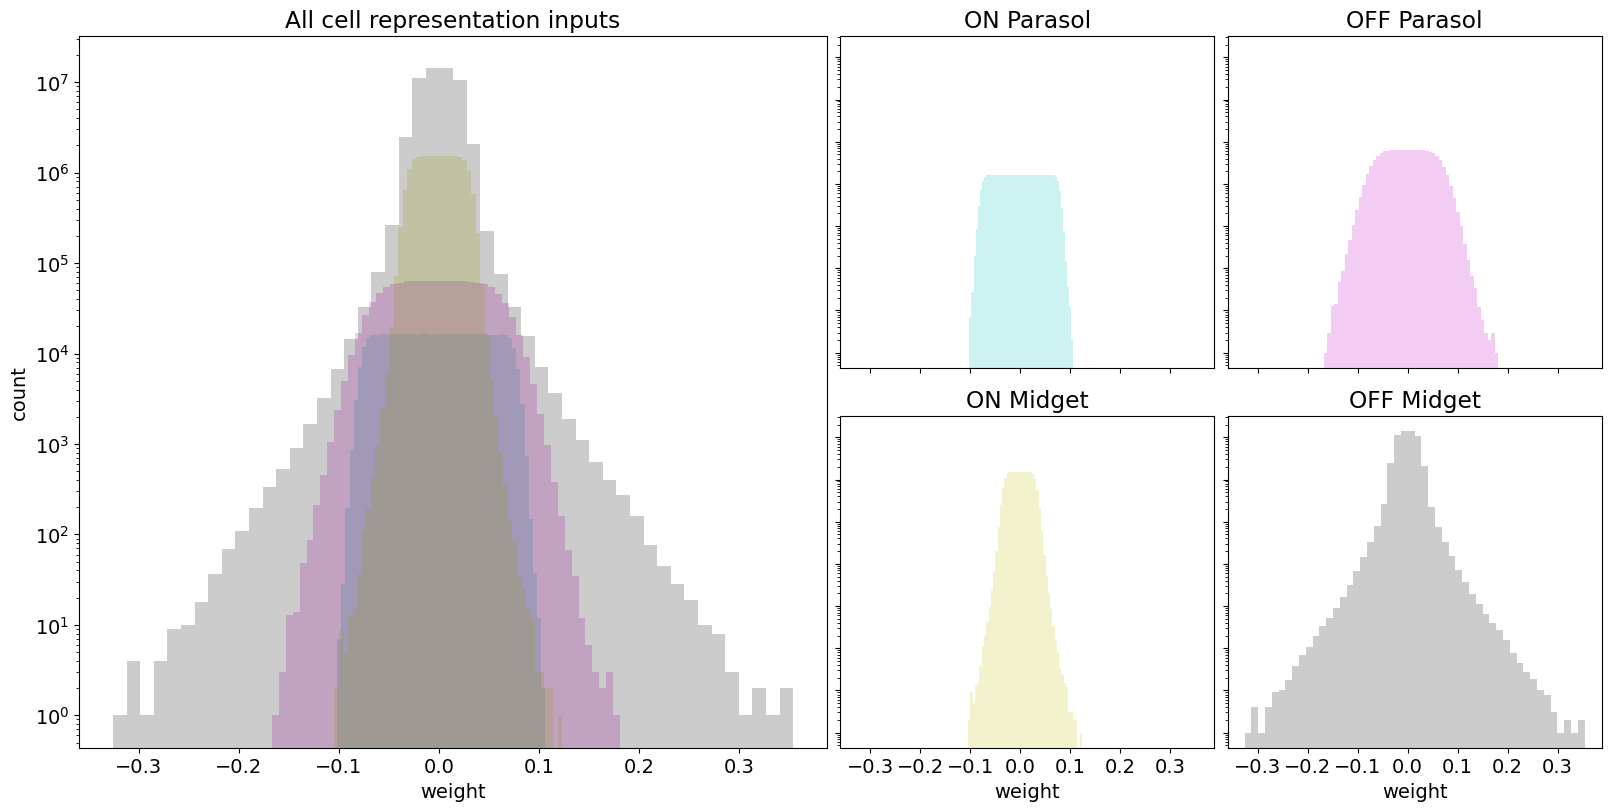

In [9]:
# let's just broadly observe via histogram to see if some values are generally higher than other
import matplotlib.pyplot as plt

# "L" spans two rows, creating a larger plot
# A, B, C, D are the four smaller plots
layout = [
    ["L", "L", "A", "B"],
    ["L", "L", "C", "D"]
]

fig, ax = plt.subplot_mosaic(layout, figsize=(16, 8), constrained_layout=True, sharex=True, sharey=True)

# plot everything together first
ax["L"].hist(weights["model_state_dict"]["w_mosaics.0.weight"].flatten(), bins=50, color="c", alpha=0.2)
ax["L"].hist(weights["model_state_dict"]["w_mosaics.1.weight"].flatten(), bins=50, color="m", alpha=0.2)
ax["L"].hist(weights["model_state_dict"]["w_mosaics.2.weight"].flatten(), bins=50, color="y", alpha=0.2)
ax["L"].hist(weights["model_state_dict"]["w_mosaics.3.weight"].flatten(), bins=50, color="k", alpha=0.2)
ax["L"].set_yscale("log")
ax["L"].set_title("All cell representation inputs")
ax["L"].set_ylabel("count")
ax["L"].set_xlabel("weight")

# then everything separately
ax["A"].hist(weights["model_state_dict"]["w_mosaics.0.weight"].flatten(), bins=50, color="c", alpha=0.2)
ax["A"].set_title("ON Parasol")

ax["B"].hist(weights["model_state_dict"]["w_mosaics.1.weight"].flatten(), bins=50, color="m", alpha=0.2)
ax["B"].set_title("OFF Parasol")

ax["C"].hist(weights["model_state_dict"]["w_mosaics.2.weight"].flatten(), bins=50, color="y", alpha=0.2)
ax["C"].set_title("ON Midget")
ax["C"].set_xlabel("weight")

ax["D"].hist(weights["model_state_dict"]["w_mosaics.3.weight"].flatten(), bins=50, color="k", alpha=0.2)
ax["D"].set_title("OFF Midget")
ax["D"].set_xlabel("weight")

plt.show()

### what's there in the outputs?
I'd like to take a deeper look into what's there in each of the outputs... essentially: are we capturing the functional properties of each of the RGC types?

you can run `python sk_extract_video_features.py` to get a baisc few features each video. i ran this for each cell type specific video and for the reconstruction overall.

In [13]:
all_cell_feats = pd.read_csv("/home/rotation/Desktop/LNP_LN_LN_Models/frame_features.csv")
onp_cell_feats = pd.read_csv("/home/rotation/Desktop/LNP_LN_LN_Models/frame_features_ONParasol.csv")
ofp_cell_feats = pd.read_csv("/home/rotation/Desktop/LNP_LN_LN_Models/frame_features_OFFParasol.csv")
onm_cell_feats = pd.read_csv("/home/rotation/Desktop/LNP_LN_LN_Models/frame_features_ONMidget.csv")
ofm_cell_feats = pd.read_csv("/home/rotation/Desktop/LNP_LN_LN_Models/frame_features_OFFMidget.csv")

all_cell_feats.head()

,frame,mean_luminance,rms_contrast,sf_ratio,edge_density,flow_magnitude
0,0,0.1300,0.0535,0.3174,0.0086,NaN
1,1,0.1298,0.0534,0.3112,0.0080,0.1389
2,2,0.1305,0.0533,0.3157,0.0081,0.1509
3,3,0.1305,0.0534,0.3185,0.0082,0.1467
4,4,0.1312,0.0535,0.3193,0.0086,0.1462


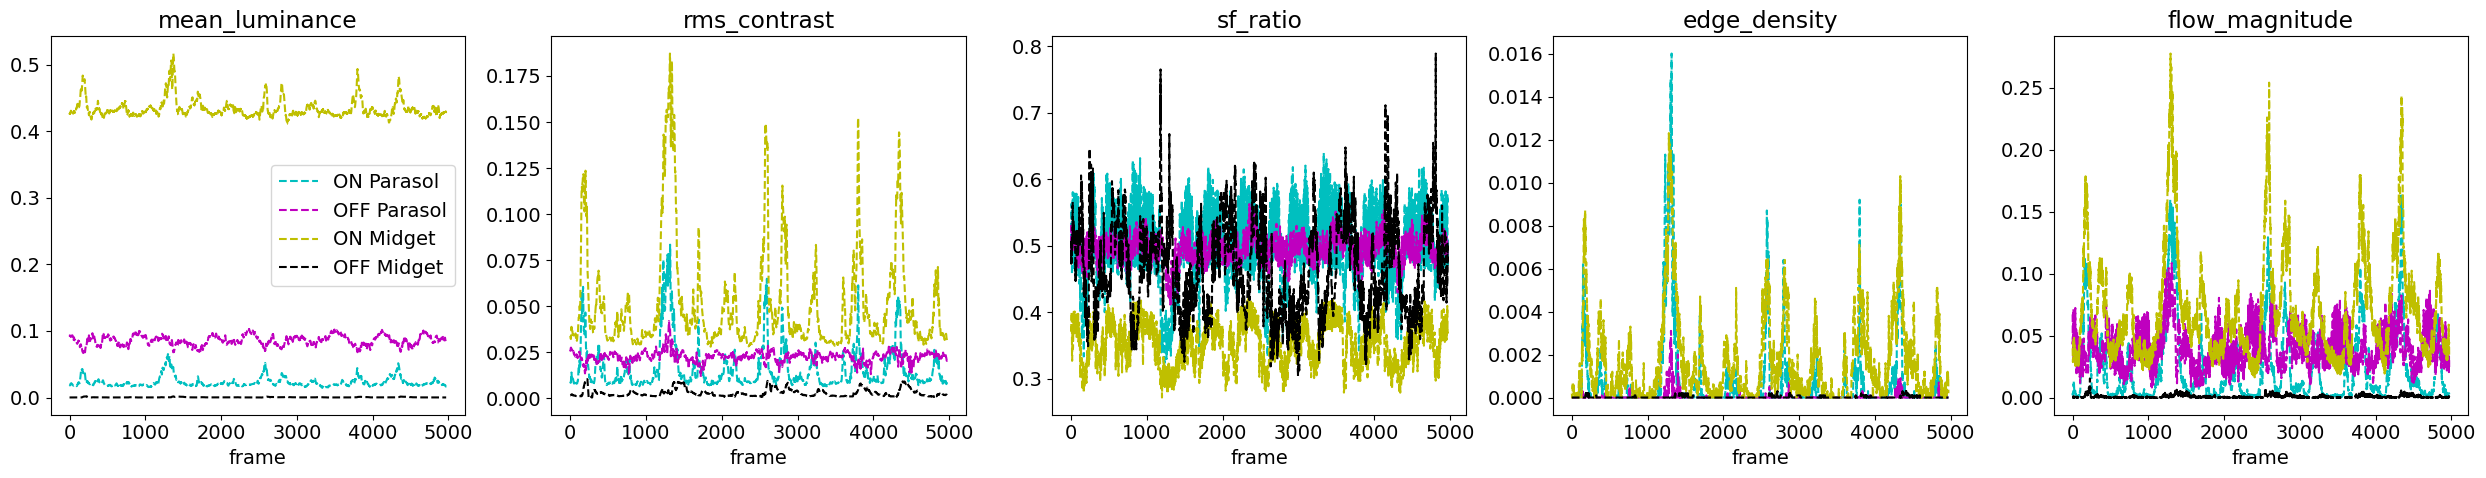

In [27]:
fig, ax = plt.subplots(1, 5, figsize=(25, 5), sharex=True)
feats = all_cell_feats.columns[1:]

for i,feat in enumerate(feats):
    #ax[i].plot(all_cell_feats["frame"], all_cell_feats[feat], c="red", label="reconstruction")
    ax[i].plot(onp_cell_feats["frame"], onp_cell_feats[feat], c="c", ls="--", label="ON Parasol")
    ax[i].plot(ofp_cell_feats["frame"], ofp_cell_feats[feat], c="m", ls="--", label="OFF Parasol")
    ax[i].plot(onm_cell_feats["frame"], onm_cell_feats[feat], c="y", ls="--", label="ON Midget")
    ax[i].plot(ofm_cell_feats["frame"], ofm_cell_feats[feat], c="k", ls="--", label="OFF Midget")
    ax[i].set_title(feat)
    ax[i].set_xlabel("frame")

ax[0].legend()

fig.set_tight_layout(True)
plt.show()

# Weights
I want to take a look at the firing rates, it seems like there is some prior encoded into them that fixes the reconstruction to have some structure. I'm thinking this has something to do with the baseline firing rate... So let's take a look

Let's pick out a patch that has relatively low motion throughout the entire video (patch 0,0 (top left corner)) from Video 2 that we know doesnt get much action. From there, we should be able to see if there is some baseline firing rate encoded (it doesn't seem like it.)

In [53]:
data = torch.load("full_video_activations/Video_2_full_activations.h5", map_location="cpu")
data.keys()

dict_keys(['activations', 'video_info'])

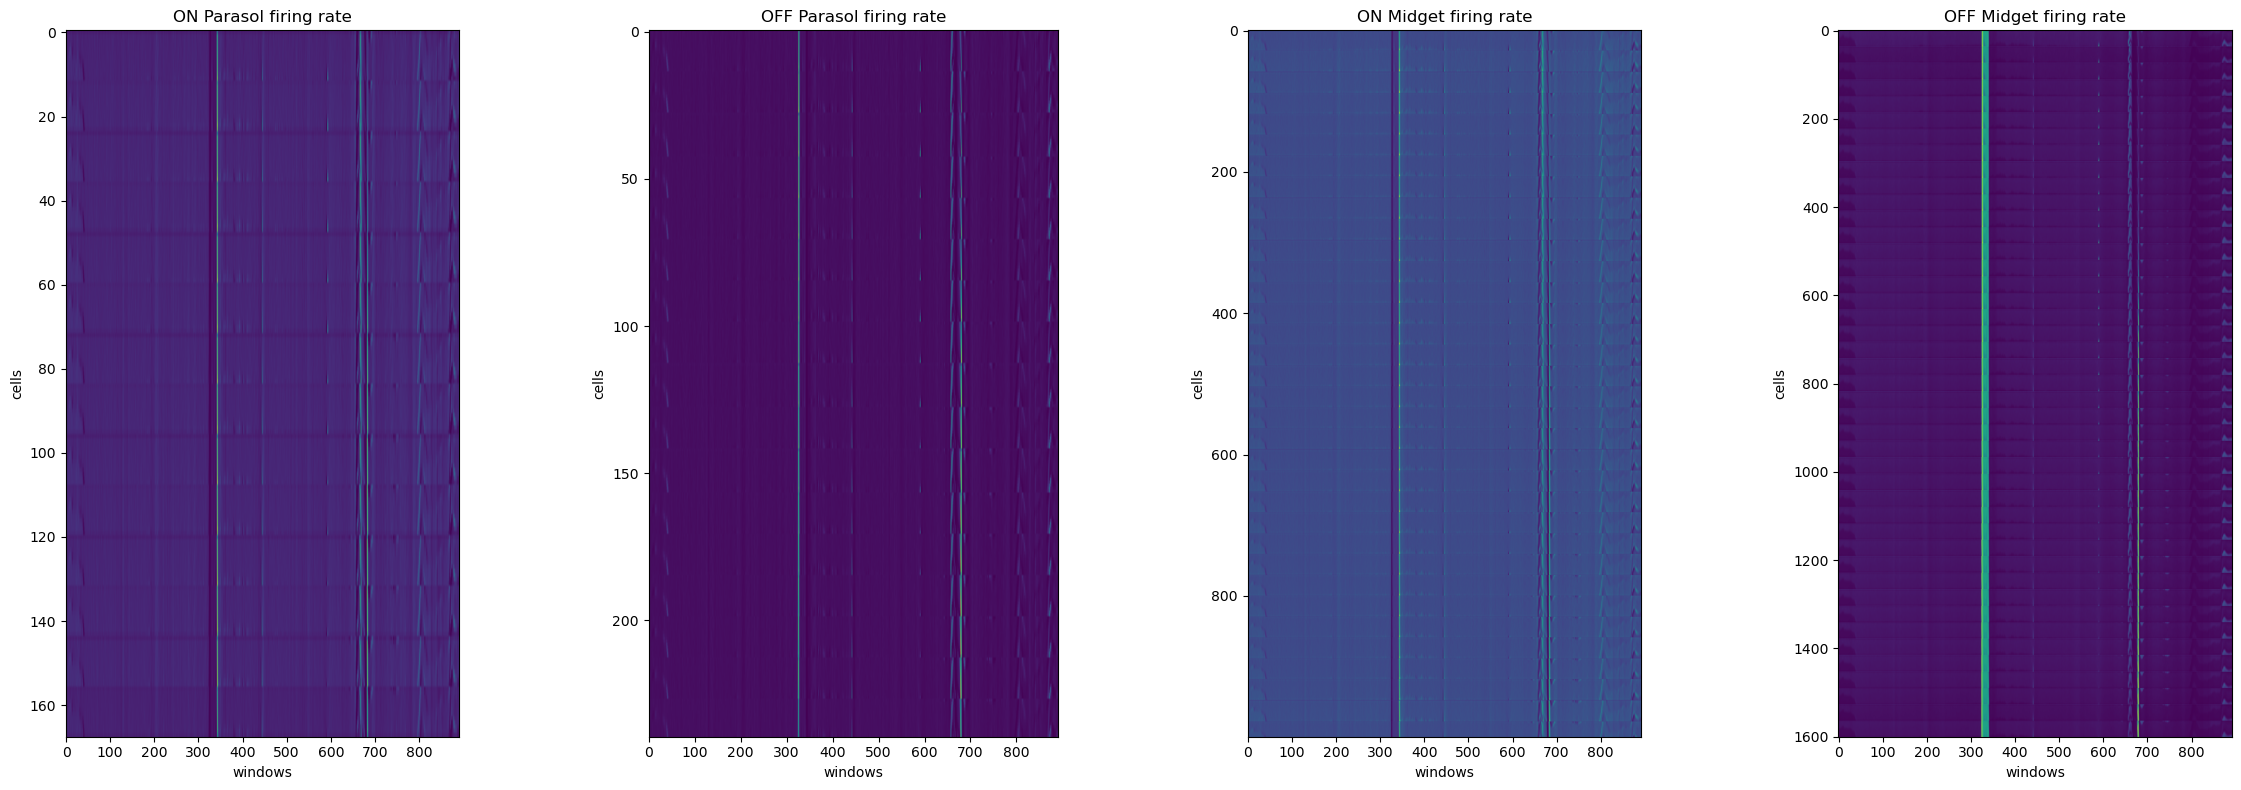

In [54]:
fig, ax = plt.subplots(1, 4, figsize=(24, 8))

ax[0].imshow(data["activations"][(0,0)][0,:168], aspect=1601/168)
ax[0].set_xlabel("windows")
ax[0].set_ylabel("cells")
ax[0].set_title("ON Parasol firing rate")

ax[1].imshow(data["activations"][(0,0)][1,:240], aspect=1601/250)
ax[1].set_xlabel("windows")
ax[1].set_ylabel("cells")
ax[1].set_title("OFF Parasol firing rate")

ax[2].imshow(data["activations"][(0,0)][2,:1000], aspect=1601/1000)
ax[2].set_xlabel("windows")
ax[2].set_ylabel("cells")
ax[2].set_title("ON Midget firing rate")

ax[3].imshow(data["activations"][(0,0)][3], aspect=1601/1601)
ax[3].set_xlabel("windows")
ax[3].set_ylabel("cells")
ax[3].set_title("OFF Midget firing rate")

fig.set_tight_layout(True)
plt.show()

clearly, there is some baseline firing rate, which should be fine since our decoder should learn how to ignore that... what's weird, though, is that there seems to be some spatially encoded prior in the decoded videos for each cell type. This is going to be a bit tough to figure out though, because we don't enforce any sort of constraints on the decoder.<br><br>

My guess is that this could be somehow encoded in the patches that we're using for training since I can't visually see anything wrong with the firing rates. My hypothesis would be that the baseline firing rate would change in a gradient-like fashion in the y direction (for each cell, the baseline firing rate would be slightly higher/lower than the preceeding cell)<br><br>

I think this would specifically come from Video 3. Since the video is smaller in size and half of the video is ground and the other half is sky, it's likely that this could be the prior encoding that we're seeing. To investigate, let's take a look at the training data from the rest of the videos. Since we took 5 patches from each video, we should see that maybe the data from Video 3 does have this sort of encoding structure.

In [40]:
data = h5py.File("lnp_activations_bank_relu/Video_1_acts.h5", "r")
data.keys()

<KeysViewHDF5 ['trials', 'video_info']>

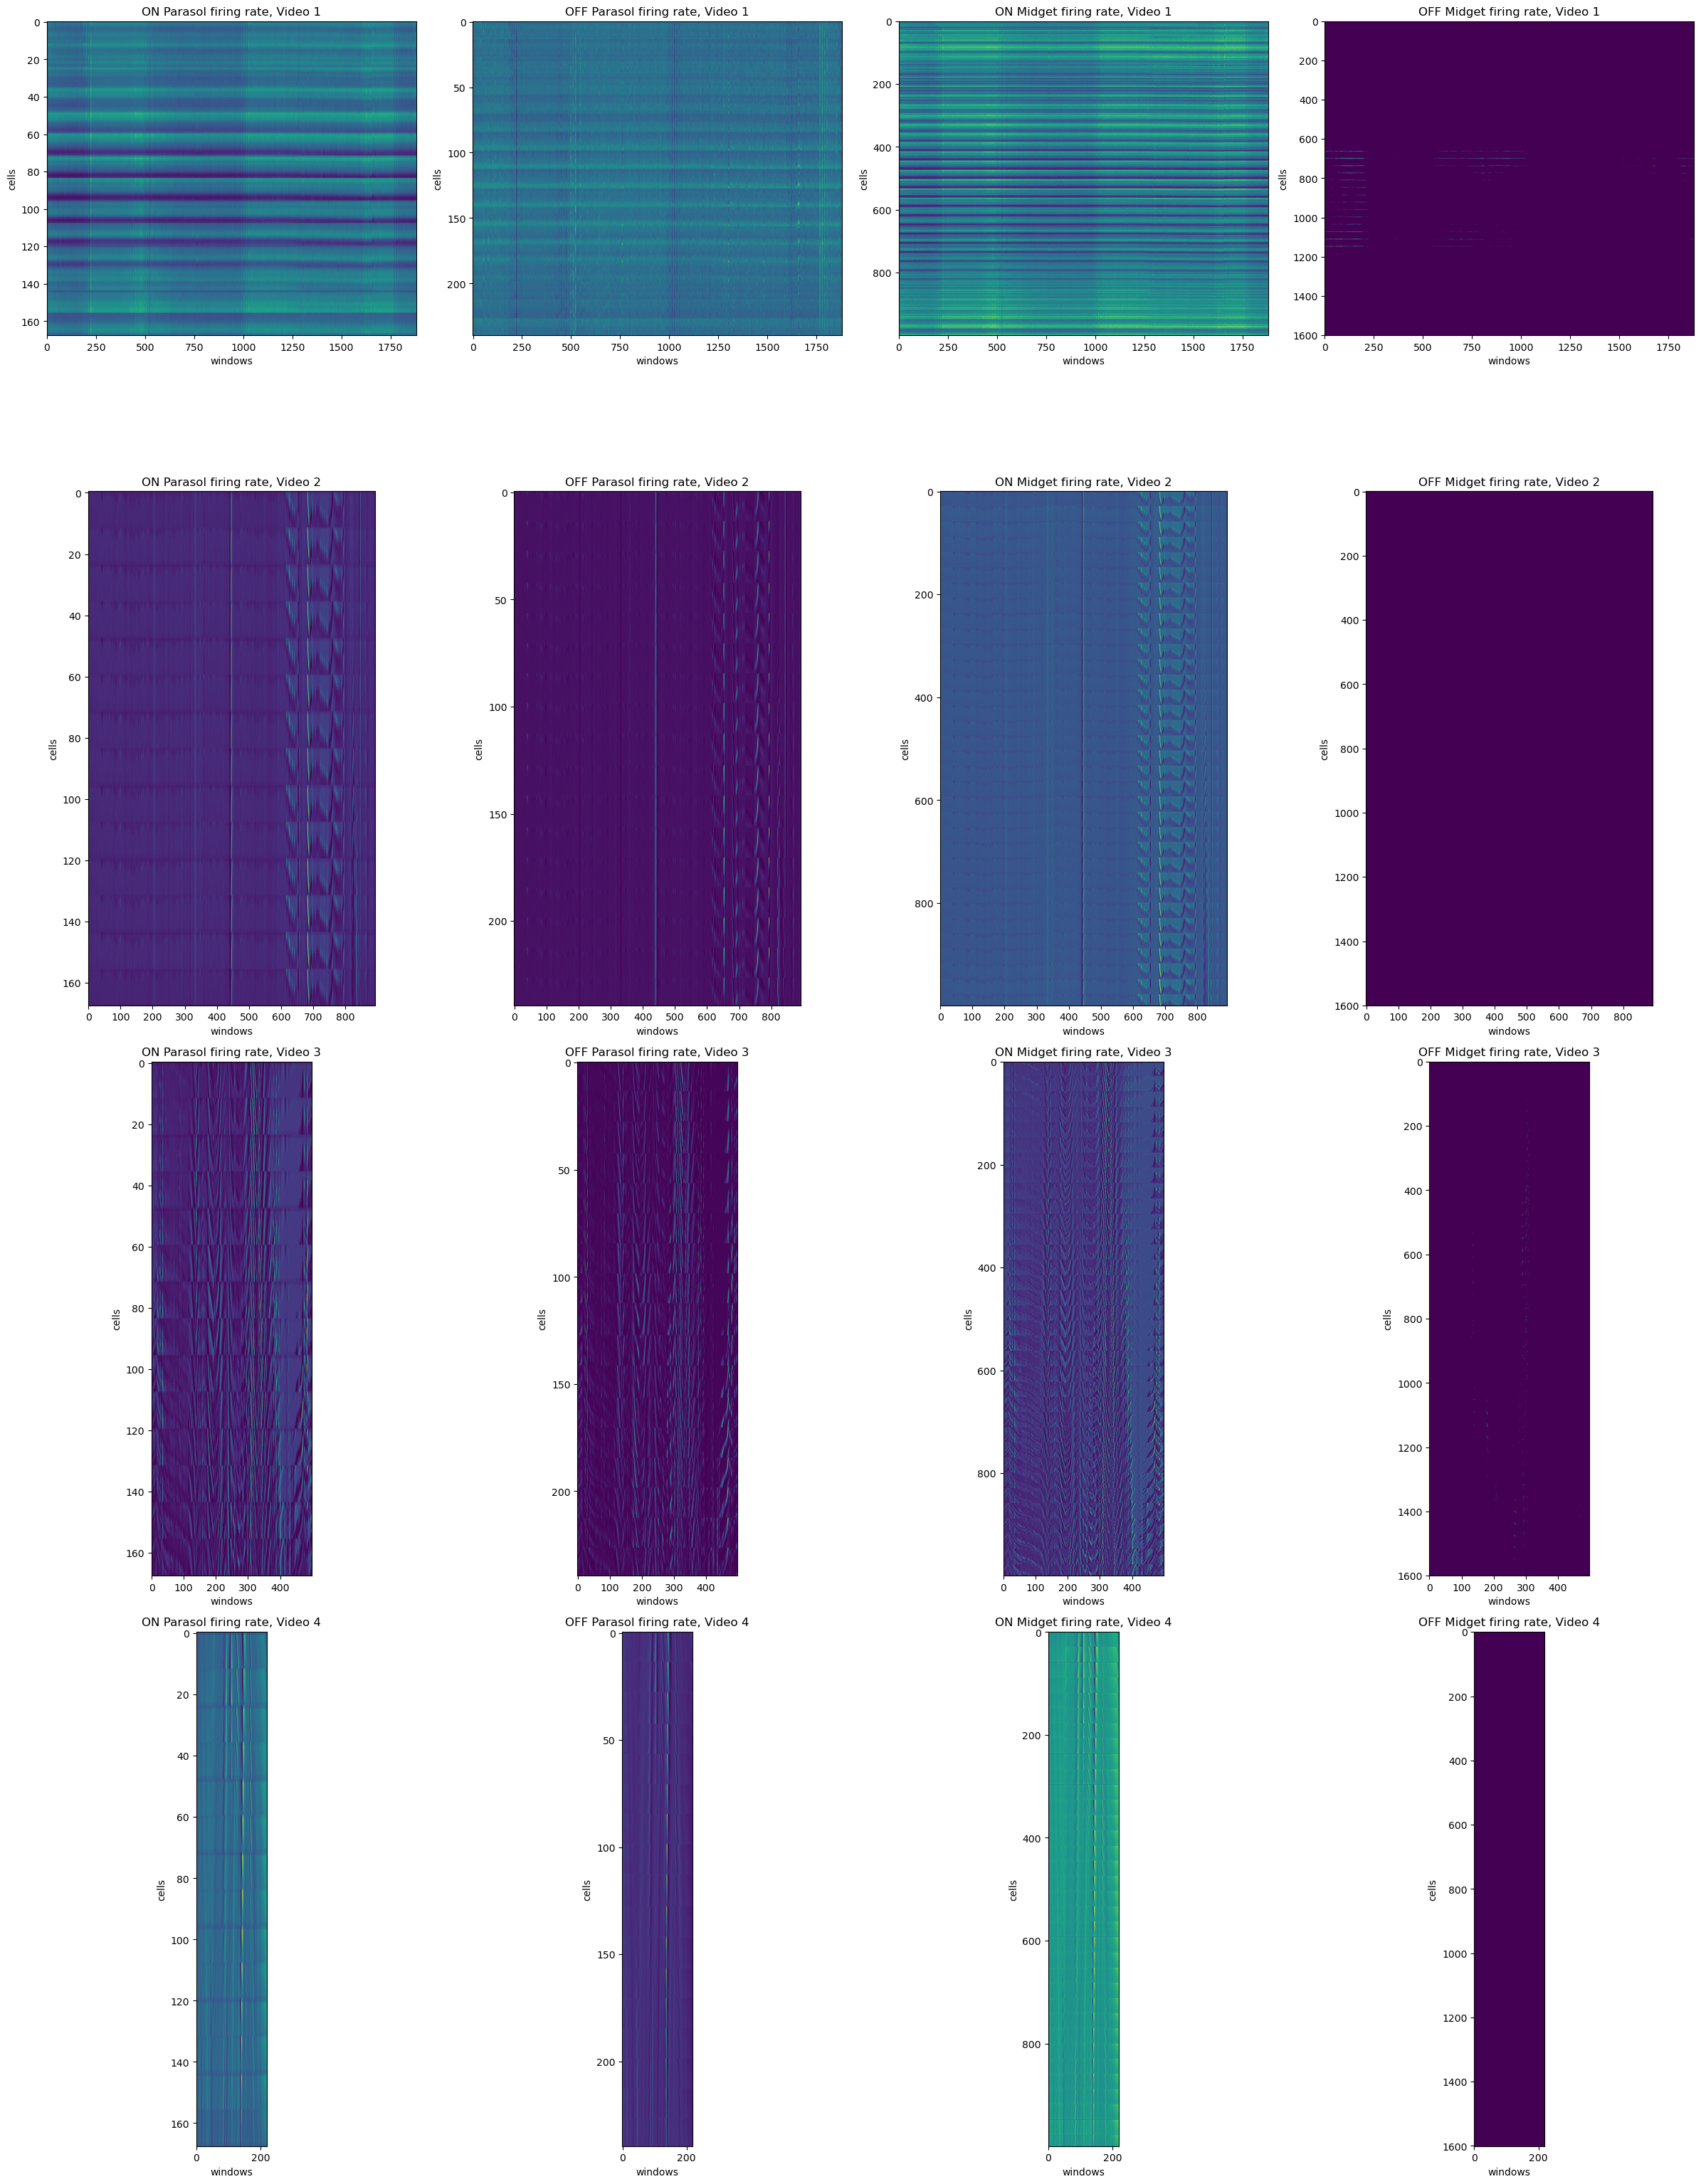

In [61]:
fig, ax = plt.subplots(4, 4, figsize=(24, 32))

# iterate over each Video activations, we'll just check one trial from each video for now
# if one trial has this gradient of baseline firing rates, that's already 1 / (4 videos * 5 trials/video) = 5% of the data
# definitely enough to encode some prior. it jumps to 25% of the data if the prior is there for ever patch from a video
for v in [1, 2, 3, 4]:
    data = h5py.File(f"lnp_activations_bank_relu/Video_{v}_acts.h5", "r")
    firing_rates = data["trials"]["4"]["firing_rates"][:]

    # for on parasol
    ax[v-1][0].imshow(firing_rates[0,:168], aspect=1601/168)
    ax[v-1][0].set_xlabel("windows")
    ax[v-1][0].set_ylabel("cells")
    ax[v-1][0].set_title(f"ON Parasol firing rate, Video {v}")

    # for off parasol
    ax[v-1][1].imshow(firing_rates[1,:240], aspect=1601/240)
    ax[v-1][1].set_xlabel("windows")
    ax[v-1][1].set_ylabel("cells")
    ax[v-1][1].set_title(f"OFF Parasol firing rate, Video {v}")

    # for on midget
    ax[v-1][2].imshow(firing_rates[2,:1000], aspect=1601/1000)
    ax[v-1][2].set_xlabel("windows")
    ax[v-1][2].set_ylabel("cells")
    ax[v-1][2].set_title(f"ON Midget firing rate, Video {v}")

    # for off midget
    ax[v-1][3].imshow(firing_rates[3], aspect=1601/1601)
    ax[v-1][3].set_xlabel("windows")
    ax[v-1][3].set_ylabel("cells")
    ax[v-1][3].set_title(f"OFF Midget firing rate, Video {v}")

fig.set_tight_layout(True)
plt.show()

hmm, just based on this qualitative data, I can't really make a case for this prior being encoded into the videos. 

I'm wondering if we just need to train on some more data...
- ie just these videos we have here encode some sort of prior like this and we just need some more data to cancel it out
- OHHH, maybe it's just that we need to add some rotation augmentations when we encode the videos and that will cancel it.

maybe this sort of prior is expected... i doubt it

maybe there is some way to quantify if this gradient is encoded into the firing rates...
- coarsely, i could just check if the avg color moves up/down down the array (this wont account for real firing across the array)
- 